# Step Metrics Overview

This chart shows the evolution of the main training metrics over **global steps**:

- **Reward**: the agent’s performance signal during training.
- **Train loss**: optimization loss values recorded intermittently.
- **Actor loss**: policy update loss values.
- **Critic loss**: value-function update loss values.

## Interpretation

- The **reward** curve is tracked continuously across the full training run.
- The **loss metrics** are much sparser, indicating they are logged only at selected training updates.
- The use of **scientific notation** on both axes helps make large step counts and small loss values easier to read.
- Together, these plots provide a quick view of both **training stability** and **learning progress** over time.

In [13]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


def _set_publication_style(base_font_size: int = 9):
    """Set matplotlib parameters for publication-quality figures."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif", "STIXGeneral"],
        "mathtext.fontset": "stix",
        "font.size": base_font_size,
        "axes.labelsize": base_font_size,
        "axes.titlesize": base_font_size + 1,
        "legend.fontsize": base_font_size - 1,
        "xtick.labelsize": base_font_size - 1,
        "ytick.labelsize": base_font_size - 1,
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.8,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
    })


def _load_train_loss_series(
    experiment_folders: dict,
    metrics_rel_path: str = os.path.join("metrics", "step_metrics.csv"),
    x_col: str = "global_step",
    y_col: str = "train_loss",
):
    loaded = {}

    for name, folder in experiment_folders.items():
        csv_path = os.path.join(folder, metrics_rel_path)
        if not os.path.exists(csv_path):
            print(f"[WARN] Missing file for {name}: {csv_path}")
            continue

        df = pd.read_csv(csv_path)
        if y_col not in df.columns:
            print(f"[WARN] '{y_col}' not found in {name}")
            continue

        y = pd.to_numeric(df[y_col], errors="coerce")
        mask = y.notna()

        if not mask.any():
            print(f"[WARN] No valid '{y_col}' values in {name}")
            continue

        if x_col in df.columns:
            x = pd.to_numeric(df[x_col], errors="coerce")
        else:
            x = pd.Series(range(len(df)))

        x = x[mask].reset_index(drop=True)
        y = y[mask].reset_index(drop=True)

        loaded[name] = {"x": x, "y": y}

    return loaded


def _smooth_series(y: pd.Series, window: int):
    if window is None or window <= 1 or len(y) < window:
        return y
    return y.rolling(window=window, min_periods=1, center=True).mean()


def _print_summary(loaded: dict, title: str):
    if not loaded:
        print(f"\n{title}: No data loaded.")
        return None

    summary_rows = []
    for name, d in loaded.items():
        summary_rows.append(
            {
                "experiment": name,
                "n_points": len(d["y"]),
                "mean_train_loss": d["y"].mean(),
                "median_train_loss": d["y"].median(),
                "min_train_loss": d["y"].min(),
                "last_train_loss": d["y"].iloc[-1],
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values("mean_train_loss")
    print(f"\n{title} (lower is better):")
    print(summary_df.to_string(index=False))
    return summary_df


def compare_train_loss_split(
    experiment_folders_left: dict,
    experiment_folders_right: dict,
    metrics_rel_path: str = os.path.join("metrics", "step_metrics.csv"),
    x_col: str = "global_step",
    y_col: str = "train_loss",
    max_points: int = None,
    smooth_window: int = 25,
    figure_size=(3.6, 2.5),
    title: str = "Train Loss",
    xlabel: str = "Training step",
    ylabel: str = "Train loss",
    base_font_size: int = 9,
    save_path: str = None,
    dpi: int = 600,
):
    _set_publication_style(base_font_size=base_font_size)

    left_loaded = _load_train_loss_series(experiment_folders_left, metrics_rel_path, x_col, y_col)
    right_loaded = _load_train_loss_series(experiment_folders_right, metrics_rel_path, x_col, y_col)

    fig, ax = plt.subplots(1, 1, figsize=figure_size)

    color_cycle = plt.get_cmap("tab10").colors
    marker_cycle = itertools.cycle(["o", "s", "^", "D", "v", "P", "X"])

    def _plot_group(group_loaded: dict, linestyle: str, group_prefix: str):
        for idx, (name, d) in enumerate(group_loaded.items()):
            x_plot = d["x"] if max_points is None else d["x"][:max_points]
            y_plot = d["y"] if max_points is None else d["y"][:max_points]
            y_plot = _smooth_series(y_plot, smooth_window)

            ax.plot(
                x_plot,
                y_plot,
                label=f"{group_prefix}{name}",
                linestyle=linestyle,
                color=color_cycle[idx % len(color_cycle)],
                marker=next(marker_cycle),
                markevery=max(1, len(x_plot) // 10),
                markersize=3.0,
                linewidth=1.9,
                alpha=0.95,
            )

    _plot_group(left_loaded, linestyle="-", group_prefix="")
    _plot_group(right_loaded, linestyle="--", group_prefix="")

    x_formatter = ScalarFormatter(useMathText=True)
    y_formatter = ScalarFormatter(useMathText=True)
    x_formatter.set_scientific(True)
    y_formatter.set_scientific(True)
    x_formatter.set_powerlimits((0, 0))
    y_formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(x_formatter)
    ax.yaxis.set_major_formatter(y_formatter)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if left_loaded or right_loaded:
        ax.legend(
            loc="best",
            frameon=False,
            ncol=1,
            handlelength=2.6,
            borderaxespad=0.3,
        )

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=dpi)
        print(f"[INFO] Figure saved to: {save_path}")

    plt.show()

    left_summary = _print_summary(left_loaded, "left summary")
    right_summary = _print_summary(right_loaded, "right summary")
    return left_summary, right_summary

[INFO] Figure saved to: C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\train_loss_publication.pdf


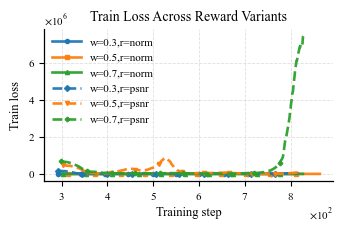


left summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.5,r=norm      1554       187.468498          32.404840      -10.726288        19.906204
w=0.7,r=norm      1646       539.747241         135.759552       -8.673832       445.888245
w=0.3,r=norm      1688       593.484402          48.972965       -2.800585       146.037048

right summary (lower is better):
  experiment  n_points  mean_train_loss  median_train_loss  min_train_loss  last_train_loss
w=0.7,r=psnr      1596     3.401741e+05       85929.292969     4529.130371     9.446442e+03
w=0.5,r=psnr      1678     1.018767e+06       23774.637695     3281.172363     4.377246e+03
w=0.3,r=psnr      1656     1.008130e+07      108026.113281     3802.958740     1.244829e+08


In [14]:
# --- Example usage (publication-ready export) ---
experiments = {
    "w=0.3,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_11-32",
    "w=0.5,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_11-48",
    "w=0.7,r=norm": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-03",
}

experiments_right = {
    "w=0.3,r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-42",
    "w=0.5,r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-28",
    "w=0.7,r=psnr": r"C:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-03-27_12-15",
}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
    max_points=500,
    smooth_window=21,
    figure_size=(3.5, 2.4),
    title="Train Loss Across Reward Variants",
    xlabel="Training step",
    ylabel="Train loss",
    base_font_size=9,
    save_path=r"C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\train_loss_publication.pdf",
    dpi=600,
)

{'latest': 'c:\\Users\\es25591\\Workspace\\CacheVideoPredict360\\Results\\2026-05-11_13-28'}
[WARN] Missing file for latest: c:\Users\es25591\Workspace\CacheVideoPredict360\Results\2026-05-11_13-28\metrics\step_metrics.csv
[INFO] Figure saved to: C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\latest_train_loss.pdf


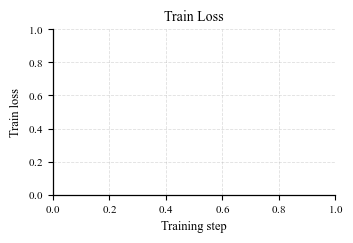


left summary: No data loaded.

right summary: No data loaded.


In [15]:
# Note: The experiments are disconsidering the warmup phase

cur_path = r"c:\Users\es25591\Workspace\CacheVideoPredict360\Results"

# --- Example usage ---
cur_f = max(
    [d for d in os.listdir(cur_path) 
     if os.path.isdir(os.path.join(cur_path, d)) and len(d) == 16],
    key=lambda x: x
)


experiments = {
    "latest": os.path.join(cur_path, cur_f)
}

print(experiments)
experiments_right = {}

left_summary, right_summary = compare_train_loss_split(
    experiments,
    experiments_right,
    x_col="global_step",
    y_col="train_loss",
    max_points=2300,
    save_path=r"C:\Users\es25591\Workspace\CacheVideoPredict360\Graphs\latest_train_loss.pdf",
)

✓ Loaded LRU: 100 episodes
✓ Loaded LFU: 100 episodes
✓ Loaded FIFO: 100 episodes


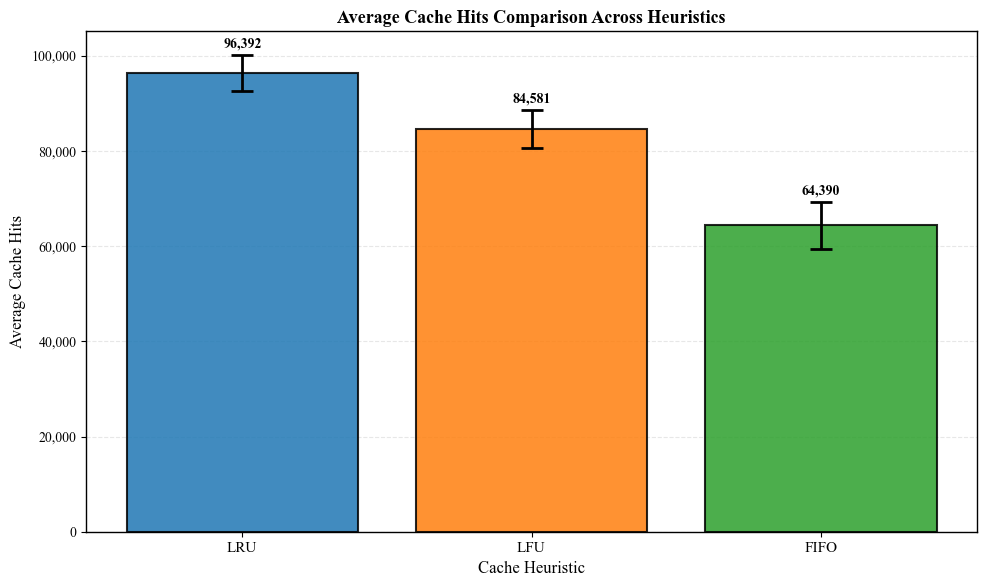


CACHE HEURISTICS COMPARISON SUMMARY

LRU:
  Avg Cache Hits per Episode: 96,392
  Total Cache Hits: 9,639,160
  Avg Cache Misses per Episode: 92,264
  Total Cache Misses: 9,226,440
  Avg Hit Rate: 51.10%
  Episodes: 100

LFU:
  Avg Cache Hits per Episode: 84,581
  Total Cache Hits: 8,458,070
  Avg Cache Misses per Episode: 104,075
  Total Cache Misses: 10,407,530
  Avg Hit Rate: 44.84%
  Episodes: 100

FIFO:
  Avg Cache Hits per Episode: 64,390
  Total Cache Hits: 6,438,969
  Avg Cache Misses per Episode: 124,266
  Total Cache Misses: 12,426,631
  Avg Hit Rate: 34.13%
  Episodes: 100

----------------------------------------------------------------------
RELATIVE PERFORMANCE (vs FIFO baseline):
  LRU: +49.70% vs FIFO
  LFU: +31.36% vs FIFO


In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuration for cache heuristics and their result directories
HEURISTICS = {
    'LRU': 'path/to/lru/result/2026-05-11_09-37',
    'LFU': 'path/to/lfu/result/2026-05-11_09-35',
    'FIFO': 'path/to/fifo/result/2026-05-11_09-33',
}

# Update with your actual result directories
HEURISTICS = {
    'LRU': os.path.join('..', 'Results', '2026-05-11_09-37'),
    'LFU': os.path.join('..', 'Results', '2026-05-11_09-35'),
    'FIFO': os.path.join('..', 'Results', '2026-05-11_09-33'),
}

def load_heuristic_metrics(heuristics: dict, metrics_file: str = 'metrics/episode_metrics.csv'):
    """Load cache metrics for each heuristic."""
    loaded_data = {}
    
    for heuristic_name, result_dir in heuristics.items():
        csv_path = os.path.join(result_dir, metrics_file)
        
        if not os.path.exists(csv_path):
            print(f"[WARN] Missing file for {heuristic_name}: {csv_path}")
            continue
        
        try:
            df = pd.read_csv(csv_path)
            loaded_data[heuristic_name] = df
            print(f"✓ Loaded {heuristic_name}: {len(df)} episodes")
        except Exception as e:
            print(f"[ERROR] Failed to load {heuristic_name}: {e}")
    
    return loaded_data

def plot_cache_hits_comparison(heuristics_data: dict, figsize=(10, 6)):
    """Plot cache hits comparison across different heuristics using bar chart."""
    
    # Set up publication-quality style
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.0,
    })
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = {'LRU': '#1f77b4', 'LFU': '#ff7f0e', 'FIFO': '#2ca02c'}
    
    # Prepare data for bar chart
    heuristic_names = []
    avg_hits = []
    std_hits = []
    
    for heuristic_name, df in heuristics_data.items():
        heuristic_names.append(heuristic_name)
        avg_hits.append(df['cache_hits'].mean())
        std_hits.append(df['cache_hits'].std())
    
    # Create bar chart
    x_pos = np.arange(len(heuristic_names))
    bar_colors = [colors.get(name, '#7f7f7f') for name in heuristic_names]
    
    bars = ax.bar(
        x_pos, 
        avg_hits, 
        yerr=std_hits,
        label=heuristic_names,
        color=bar_colors,
        alpha=0.85,
        capsize=8,
        edgecolor='black',
        linewidth=1.5,
        error_kw={'elinewidth': 2, 'capthick': 2}
    )
    
    # Add value labels on top of bars
    for i, (bar, val, std) in enumerate(zip(bars, avg_hits, std_hits)):
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            val + std + 1000,
            f'{val:,.0f}',
            ha='center', 
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    ax.set_xlabel('Cache Heuristic', fontsize=12)
    ax.set_ylabel('Average Cache Hits', fontsize=12)
    ax.set_title('Average Cache Hits Comparison Across Heuristics', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(heuristic_names)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    
    # Format y-axis with thousands separator
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig('cache_hits_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

def print_heuristics_summary(heuristics_data: dict):
    """Print summary statistics for each heuristic."""
    print("\n" + "="*70)
    print("CACHE HEURISTICS COMPARISON SUMMARY")
    print("="*70)
    
    for heuristic_name, df in heuristics_data.items():
        avg_hits = df['cache_hits'].mean()
        total_hits = df['cache_hits'].sum()
        avg_misses = df['cache_misses'].mean()
        total_misses = df['cache_misses'].sum()
        avg_hit_rate = df['hit_rate'].mean() * 100
        
        print(f"\n{heuristic_name}:")
        print(f"  Avg Cache Hits per Episode: {avg_hits:,.0f}")
        print(f"  Total Cache Hits: {total_hits:,.0f}")
        print(f"  Avg Cache Misses per Episode: {avg_misses:,.0f}")
        print(f"  Total Cache Misses: {total_misses:,.0f}")
        print(f"  Avg Hit Rate: {avg_hit_rate:.2f}%")
        print(f"  Episodes: {len(df)}")
    
    # Print improvement percentages
    if len(heuristics_data) > 1:
        print("\n" + "-"*70)
        print("RELATIVE PERFORMANCE (vs FIFO baseline):")
        
        baseline = heuristics_data.get('FIFO')
        if baseline is not None:
            baseline_hits = baseline['cache_hits'].mean()
            
            for heuristic_name, df in heuristics_data.items():
                if heuristic_name == 'FIFO':
                    continue
                hits = df['cache_hits'].mean()
                improvement = ((hits - baseline_hits) / baseline_hits) * 100
                print(f"  {heuristic_name}: {improvement:+.2f}% vs FIFO")

# Load data and plot
heuristics_data = load_heuristic_metrics(HEURISTICS)

if heuristics_data:
    plot_cache_hits_comparison(heuristics_data)
    print_heuristics_summary(heuristics_data)
else:
    print("[ERROR] No heuristics data loaded. Please update HEURISTICS paths.")

✓ Loaded A2C (5%): 30 episodes
✓ Loaded LFU (5%): 100 episodes
✓ Loaded LRU (5%): 100 episodes
✓ Loaded FIFO (5%): 100 episodes
✓ Loaded A2C (10%): 35 episodes
✓ Loaded LFU (10%): 100 episodes
✓ Loaded LRU (10%): 100 episodes
✓ Loaded FIFO (10%): 100 episodes
✓ Loaded A2C (15%): 30 episodes
✓ Loaded LFU (15%): 100 episodes
✓ Loaded LRU (15%): 100 episodes
✓ Loaded FIFO (15%): 100 episodes
✓ Loaded A2C (20%): 66 episodes
✓ Loaded LFU (20%): 100 episodes
✓ Loaded LRU (20%): 100 episodes
✓ Loaded FIFO (20%): 100 episodes

[INFO] Generating multi-scenario grouped bar chart...


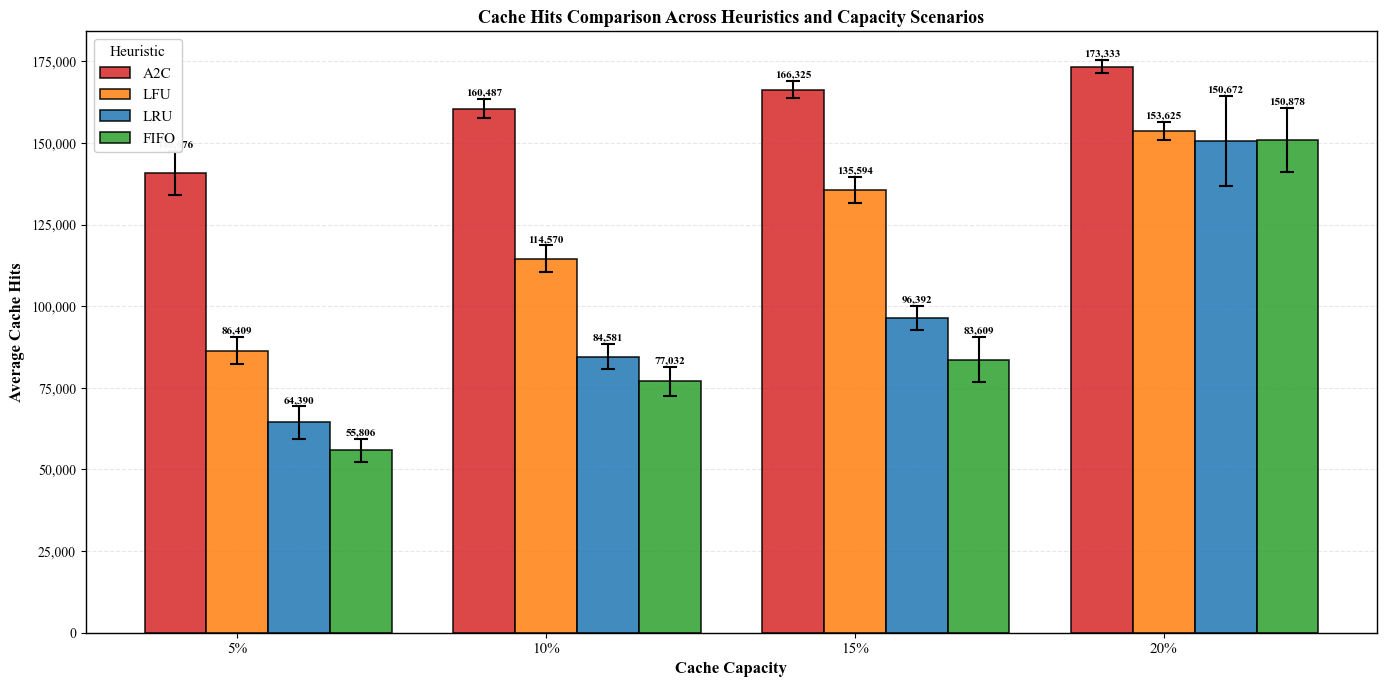


[INFO] Generating trend lines...


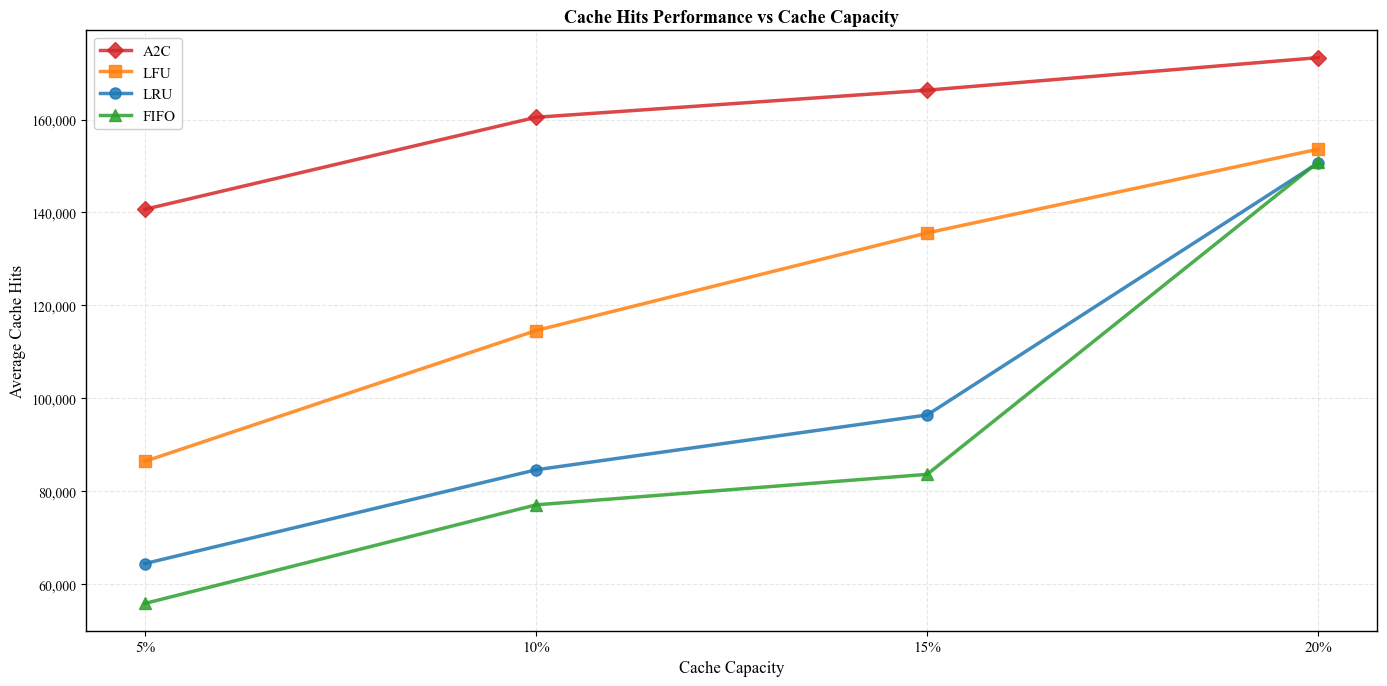


[INFO] Printing summary statistics...

MULTI-SCENARIO CACHE HEURISTICS COMPARISON SUMMARY

------------------------------------------------------------------------------------------
CACHE CAPACITY: 5%
------------------------------------------------------------------------------------------

A2C:
  Avg Cache Hits per Episode: 140,676
  Total Cache Hits: 4,220,286
  Avg Cache Misses per Episode: 47,606
  Avg Hit Rate: 74.72%

FIFO:
  Avg Cache Hits per Episode: 55,806
  Total Cache Hits: 5,580,648
  Avg Cache Misses per Episode: 132,850
  Avg Hit Rate: 29.58%

LFU:
  Avg Cache Hits per Episode: 86,409
  Total Cache Hits: 8,640,934
  Avg Cache Misses per Episode: 102,247
  Avg Hit Rate: 45.80%

LRU:
  Avg Cache Hits per Episode: 64,390
  Total Cache Hits: 6,438,969
  Avg Cache Misses per Episode: 124,266
  Avg Hit Rate: 34.13%

------------------------------------------------------------------------------------------
CACHE CAPACITY: 10%
--------------------------------------------------

In [17]:
# Multi-Scenario Comparison: Heuristics across different cache capacities

# Define heuristics and their result directories for different cache capacities
CAPACITY_SCENARIOS = {
    '5%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_10-53'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-42'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-33'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-01'),
    },
    '10%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_11-10'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-44'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-35'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-12'),
    },
    '15%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_11-31'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-47'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-37'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-32'),
    },
    '20%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_11-46'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_09-50'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_09-40'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_10-38'),
    },
}

def load_multi_scenario_metrics(capacity_scenarios: dict, metrics_file: str = 'metrics/episode_metrics.csv'):
    """Load cache metrics for each heuristic across all capacity scenarios."""
    loaded_data = {}
    
    for capacity, heuristics in capacity_scenarios.items():
        loaded_data[capacity] = {}
        for heuristic_name, result_dir in heuristics.items():
            csv_path = os.path.join(result_dir, metrics_file)
            
            if not os.path.exists(csv_path):
                print(f"[WARN] Missing file for {heuristic_name} ({capacity}): {csv_path}")
                continue
            
            try:
                df = pd.read_csv(csv_path)
                loaded_data[capacity][heuristic_name] = df
                print(f"✓ Loaded {heuristic_name} ({capacity}): {len(df)} episodes")
            except Exception as e:
                print(f"[ERROR] Failed to load {heuristic_name} ({capacity}): {e}")
    
    return loaded_data

def plot_heuristics_by_capacity(capacity_scenarios_data: dict, figsize=(14, 7)):
    """Plot cache hits as grouped bars: capacities on x-axis, heuristics as groups."""
    
    # Set up publication-quality style
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.0,
    })
    
    fig, ax = plt.subplots(figsize=figsize)
    
    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    
    colors = {'LFU': '#ff7f0e', 'LRU': '#1f77b4', 'FIFO': '#2ca02c', 'A2C': '#d62728'}
    
    # Prepare data for grouped bar chart
    x = np.arange(len(capacities))
    width = 0.2  # Width of each bar
    
    # Store bar containers for value labels
    all_bars = []
    all_vals = []
    all_stds = []
    
    for idx, heuristic in enumerate(heuristics):
        avg_hits = []
        std_hits = []
        
        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_hits.append(df['cache_hits'].mean())
                std_hits.append(df['cache_hits'].std())
            else:
                avg_hits.append(0)
                std_hits.append(0)

        # Position bars for this heuristic
        offset = width * (idx - 1)
        bars = ax.bar(
            x + offset, 
            avg_hits, 
            width,
            yerr=std_hits,
            label=heuristic,
            color=colors.get(heuristic, '#7f7f7f'),
            alpha=0.85,
            capsize=5,
            edgecolor='black',
            linewidth=1.2,
            error_kw={'elinewidth': 1.5, 'capthick': 1.5}
        )
        
        all_bars.append(bars)
        all_vals.append(avg_hits)
        all_stds.append(std_hits)
    
    # Add value labels on top of each bar
    for bars, vals, stds in zip(all_bars, all_vals, all_stds):
        for bar, val, std in zip(bars, vals, stds):
            if val > 0:  # Only label non-empty bars
                ax.text(
                    bar.get_x() + bar.get_width() / 2, 
                    val + std + 500,
                    f'{val:,.0f}',
                    ha='center', 
                    va='bottom',
                    fontsize=8,
                    fontweight='bold'
                )
    
    # Customize axes
    ax.set_xlabel('Cache Capacity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Cache Hits', fontsize=12, fontweight='bold')
    ax.set_title('Cache Hits Comparison Across Heuristics and Capacity Scenarios', 
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.legend(loc='upper left', framealpha=0.95, title='Heuristic', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig('heuristics_capacity_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

def plot_heuristics_line_by_capacity(capacity_scenarios_data: dict, figsize=(14, 7)):
    """Plot average cache hits as lines for each heuristic across capacity scenarios."""

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.5,
    })

    fig, ax = plt.subplots(figsize=figsize)

    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    
    colors = { 'A2C': '#d62728', 'LRU': '#1f77b4', 'LFU': '#ff7f0e', 'FIFO': '#2ca02c'}
    markers = {'LFU': 's', 'LRU': 'o', 'FIFO': '^', 'A2C': 'D'}
    
    # Prepare data for each heuristic
    for heuristic in heuristics:
        avg_hits_list = []
        
        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_hits_list.append(df['cache_hits'].mean())
            else:
                avg_hits_list.append(None)
        
        # Plot line for this heuristic
        ax.plot(
            capacities,
            avg_hits_list,
            label=heuristic,
            linewidth=2.5,
            color=colors.get(heuristic),
            marker=markers.get(heuristic),
            markersize=8,
            alpha=0.85
        )
    
    ax.set_xlabel('Cache Capacity', fontsize=12)
    ax.set_ylabel('Average Cache Hits', fontsize=12)
    ax.set_title('Cache Hits Performance vs Cache Capacity', fontsize=13, fontweight='bold')
    ax.legend(loc='best', framealpha=0.95)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig('heuristics_capacity_trends.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

def print_multi_scenario_summary(capacity_scenarios_data: dict):
    """Print summary statistics for each heuristic across all capacity scenarios."""
    print("\n" + "="*90)
    print("MULTI-SCENARIO CACHE HEURISTICS COMPARISON SUMMARY")
    print("="*90)
    
    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    
    for capacity in capacities:
        print(f"\n{'-'*90}")
        print(f"CACHE CAPACITY: {capacity}")
        print(f"{'-'*90}")
        
        for heuristic_name, df in sorted(capacity_scenarios_data[capacity].items()):
            avg_hits = df['cache_hits'].mean()
            total_hits = df['cache_hits'].sum()
            avg_misses = df['cache_misses'].mean()
            avg_hit_rate = df['hit_rate'].mean() * 100
            
            print(f"\n{heuristic_name}:")
            print(f"  Avg Cache Hits per Episode: {avg_hits:,.0f}")
            print(f"  Total Cache Hits: {total_hits:,.0f}")
            print(f"  Avg Cache Misses per Episode: {avg_misses:,.0f}")
            print(f"  Avg Hit Rate: {avg_hit_rate:.2f}%")

# Load data and plot multi-scenario comparison
capacity_scenarios_data = load_multi_scenario_metrics(CAPACITY_SCENARIOS)

if capacity_scenarios_data:
    print("\n[INFO] Generating multi-scenario grouped bar chart...")
    plot_heuristics_by_capacity(capacity_scenarios_data)
    
    print("\n[INFO] Generating trend lines...")
    plot_heuristics_line_by_capacity(capacity_scenarios_data)
    
    print("\n[INFO] Printing summary statistics...")
    print_multi_scenario_summary(capacity_scenarios_data)
else:
    print("[ERROR] No multi-scenario data loaded. Please update CAPACITY_SCENARIOS paths.")

✓ Loaded A2C (5%): 72 episodes
✓ Loaded LFU (5%): 100 episodes
✓ Loaded LRU (5%): 100 episodes
✓ Loaded FIFO (5%): 100 episodes
✓ Loaded A2C (10%): 30 episodes
✓ Loaded LFU (10%): 100 episodes
✓ Loaded LRU (10%): 100 episodes
✓ Loaded FIFO (10%): 100 episodes
✓ Loaded A2C (15%): 30 episodes
✓ Loaded LFU (15%): 100 episodes
✓ Loaded LRU (15%): 100 episodes
✓ Loaded FIFO (15%): 100 episodes
✓ Loaded LFU (20%): 100 episodes
✓ Loaded LRU (20%): 100 episodes
✓ Loaded FIFO (20%): 100 episodes

[INFO] Generating multi-scenario grouped bar chart...


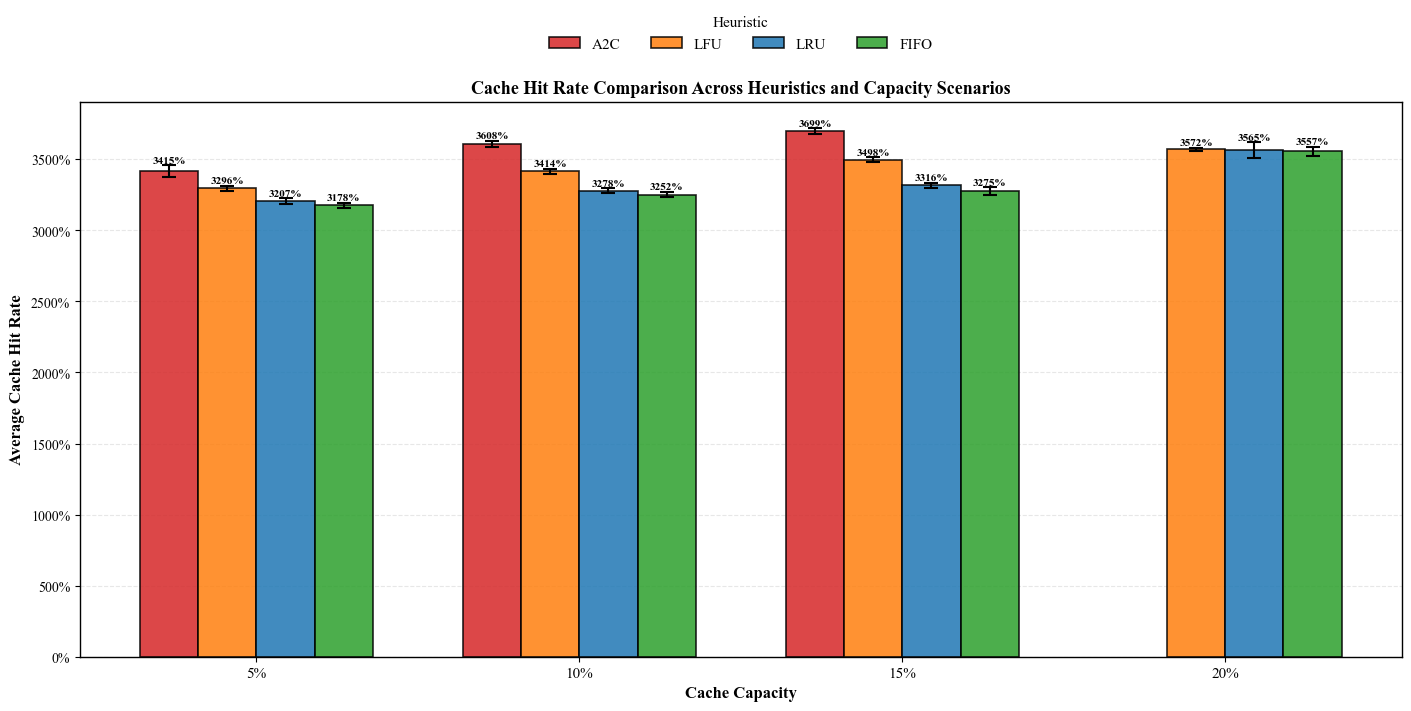

In [ ]:
# Multi-Scenario Comparison: Heuristics across different cache capacities

# Define heuristics and their result directories for different cache capacities
CAPACITY_SCENARIOS = {
    '5%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-01'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-07'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-22'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-18'),
    },
    '10%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-35'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-10'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-27'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-22'),
    },
    '15%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-50'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-12'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-28'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-25'),
    },
    '20%': {
        'A2C': os.path.join('..', 'Results', '2026-05-11_14-50'),
        'LFU': os.path.join('..', 'Results', '2026-05-11_13-15'),
        'LRU': os.path.join('..', 'Results', '2026-05-11_12-36'),
        'FIFO': os.path.join('..', 'Results', '2026-05-11_13-28'),
    },
}

def load_multi_scenario_metrics(capacity_scenarios: dict, metrics_file: str = 'metrics/episode_metrics.csv'):
    """Load cache metrics for each heuristic across all capacity scenarios."""
    loaded_data = {}

    for capacity, heuristics in capacity_scenarios.items():
        loaded_data[capacity] = {}
        for heuristic_name, result_dir in heuristics.items():
            csv_path = os.path.join(result_dir, metrics_file)

            if not os.path.exists(csv_path):
                print(f"[WARN] Missing file for {heuristic_name} ({capacity}): {csv_path}")
                continue

            try:
                df = pd.read_csv(csv_path)
                loaded_data[capacity][heuristic_name] = df
                print(f"✓ Loaded {heuristic_name} ({capacity}): {len(df)} episodes")
            except Exception as e:
                print(f"[ERROR] Failed to load {heuristic_name} ({capacity}): {e}")

    return loaded_data

def plot_heuristics_by_capacity(capacity_scenarios_data: dict, figsize=(14, 7)):
    """Plot cache hit rate as grouped bars: capacities on x-axis, heuristics as groups."""

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 10,
        "axes.linewidth": 1.0,
        "lines.linewidth": 2.0,
    })

    capacities = sorted(capacity_scenarios_data.keys(), key=lambda x: int(x.rstrip('%')))
    heuristics = list(capacity_scenarios_data[capacities[0]].keys())
    colors = {'LFU': '#ff7f0e', 'LRU': '#1f77b4', 'FIFO': '#2ca02c', 'A2C': '#d62728'}

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    x = np.arange(len(capacities))
    width = 0.18 if len(heuristics) >= 4 else 0.22

    for idx, heuristic in enumerate(heuristics):
        avg_chr = []
        std_chr = []

        for capacity in capacities:
            if heuristic in capacity_scenarios_data[capacity]:
                df = capacity_scenarios_data[capacity][heuristic]
                avg_chr.append(df['psnr'].mean())
                std_chr.append(df['psnr'].std())
            else:
                avg_chr.append(np.nan)
                std_chr.append(0)

        offset = width * (idx - (len(heuristics) - 1) / 2)
        bars = ax.bar(
            x + offset,
            avg_chr,
            width,
            yerr=std_chr,
            label=heuristic,
            color=colors.get(heuristic, '#7f7f7f'),
            alpha=0.85,
            capsize=5,
            edgecolor='black',
            linewidth=1.2,
            error_kw={'elinewidth': 1.5, 'capthick': 1.5},
        )

        for bar, val, std in zip(bars, avg_chr, std_chr):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + (std if pd.notna(std) else 0) + 0.01,
                    f'{val:.0%}',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    fontweight='bold',
                )

    ax.set_xlabel('Cache Capacity', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Cache Hit Rate', fontsize=12, fontweight='bold')
    ax.set_title('Cache Hit Rate Comparison Across Heuristics and Capacity Scenarios', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(capacities)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=len(heuristics), frameon=False, title='Heuristic')
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax.set_axisbelow(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, position: f'{value:.0%}'))

    plt.savefig('heuristics_capacity_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig, ax

# Load data and plot multi-scenario comparison
capacity_scenarios_data = load_multi_scenario_metrics(CAPACITY_SCENARIOS)

if capacity_scenarios_data:
    print("\n[INFO] Generating multi-scenario grouped bar chart...")
    plot_heuristics_by_capacity(capacity_scenarios_data)
else:
    print("[ERROR] No multi-scenario data loaded. Please update CAPACITY_SCENARIOS paths.")